retrain

In [1]:
import os
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from torchvision.models import resnet50
from torchvision.models import ResNet50_Weights

from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

import os
import torch

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

print("Torch Version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Torch Version: 2.11.0+cu128
Device: cuda


In [2]:
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
CUDA: 12.8
Available: True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
import os

print(os.getcwd())

d:\DL_Project\Google_colab


In [29]:
import os
from PIL import Image

root = "document_dataset"

removed = 0

for folder, _, files in os.walk(root):

    for file in files:

        if file.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff")):

            path = os.path.join(folder,file)

            try:

                img = Image.open(path)
                img.verify()

            except Exception:

                print("Removing:", path)

                os.remove(path)

                removed += 1

print(f"\nRemoved {removed} corrupted images.")

Removing: document_dataset\train\scientific_publication\2500126531_2500126536.tif

Removed 1 corrupted images.


In [30]:
import os

parent_folder = "document_dataset"

folders = [
    folder
    for folder in os.listdir(parent_folder)
    if os.path.isdir(os.path.join(parent_folder, folder))
]

print(folders)

['test', 'train', 'val']


In [31]:
TRAIN_DIR = r"document_dataset/train"
VAL_DIR = r"document_dataset/val"
TEST_DIR = r"document_dataset/test"

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 2

In [32]:
train_transform = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(
        224,
        scale=(0.95, 1.0)
    ),

    transforms.RandomRotation(
        degrees=2,
        fill=255
    ),

    transforms.RandomAffine(
        degrees=2,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),

    transforms.RandomGrayscale(
        p=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

In [33]:
test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )

])

In [34]:
train_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=VAL_DIR,
    transform=test_transform
)

test_dataset = ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

In [36]:
print("="*60)

print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Test Images :", len(test_dataset))

print("="*60)

print("Number of Classes :", len(train_dataset.classes))

print("="*60)

print(train_dataset.classes)

Training Images : 34637
Validation Images : 4330
Test Images : 4339
Number of Classes : 18
['adhar', 'advertisement', 'budget', 'email', 'file_folder', 'form', 'handwritten', 'invoice', 'letter', 'memo', 'news_article', 'pan', 'presentation', 'questionnaire', 'resume', 'scientific_publication', 'scientific_report', 'specification']


In [37]:
from collections import Counter

counter = Counter()

for _, label in train_dataset.samples:
    counter[label] += 1

idx_to_class = {
    v:k
    for k,v in train_dataset.class_to_idx.items()
}

print("="*60)

for idx,count in sorted(counter.items()):

    print(
        f"{idx_to_class[idx]:30s} {count}"
    )

adhar                          1481
advertisement                  2012
budget                         2004
email                          2012
file_folder                    2021
form                           2004
handwritten                    2025
invoice                        1981
letter                         1971
memo                           1993
news_article                   1970
pan                            1166
presentation                   1991
questionnaire                  1948
resume                         2028
scientific_publication         2055
scientific_report              1998
specification                  1977


In [38]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [39]:
images, labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


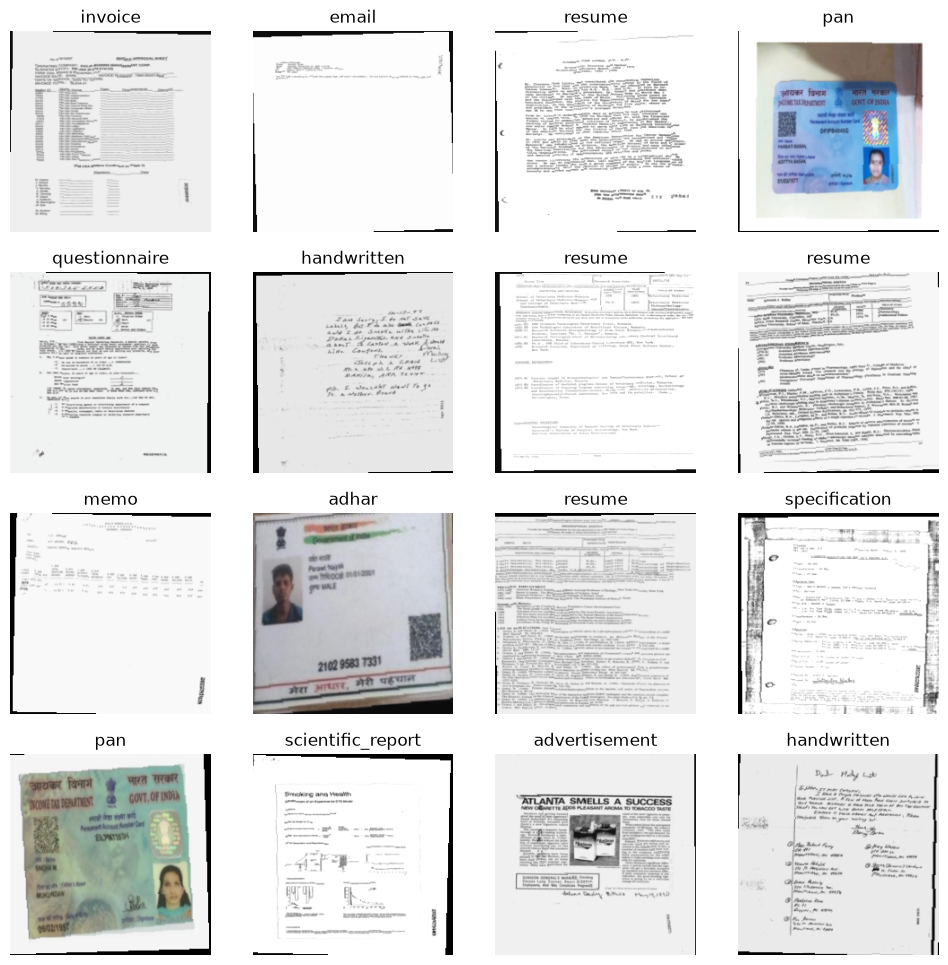

In [40]:
import matplotlib.pyplot as plt

mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

fig = plt.figure(figsize=(12,12))

for i in range(16):

    img = images[i] * std + mean

    img = img.permute(1,2,0)

    plt.subplot(4,4,i+1)

    plt.imshow(img)

    plt.title(train_dataset.classes[labels[i]])

    plt.axis("off")

plt.show()

In [41]:
type(train_dataset)

torchvision.datasets.folder.ImageFolder

In [42]:
# ==========================================================
# Load Pretrained ResNet50 for Transfer Learning
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np

from sklearn.utils.class_weight import compute_class_weight

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

# ----------------------------------------------------------
# Device
# ----------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device : {device}")

# ----------------------------------------------------------
# Number of Classes
# ----------------------------------------------------------

NUM_CLASSES = len(train_dataset.classes)

print(f"Number of Classes : {NUM_CLASSES}")

print("\nClasses\n")

for i, cls in enumerate(train_dataset.classes):

    print(f"{i:2d} : {cls}")

# ----------------------------------------------------------
# Load ImageNet Pretrained ResNet50
# ----------------------------------------------------------

weights = ResNet50_Weights.DEFAULT

model = resnet50(
    weights=weights
)

# ----------------------------------------------------------
# Freeze Entire Backbone
# ----------------------------------------------------------

for param in model.parameters():

    param.requires_grad = False

# ----------------------------------------------------------
# Replace Classification Head
# ----------------------------------------------------------

model.fc = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(

        model.fc.in_features,

        NUM_CLASSES

    )

)

# ----------------------------------------------------------
# Fine-tune Last Two Residual Blocks
# ----------------------------------------------------------

for param in model.layer3.parameters():

    param.requires_grad = True

for param in model.layer4.parameters():

    param.requires_grad = True

# ----------------------------------------------------------
# Train Classification Head
# ----------------------------------------------------------

for param in model.fc.parameters():

    param.requires_grad = True

# ----------------------------------------------------------
# Move Model to GPU
# ----------------------------------------------------------

model = model.to(device)

# ----------------------------------------------------------
# Compute Automatic Class Weights
# ----------------------------------------------------------

weights = compute_class_weight(

    class_weight="balanced",

    classes=np.unique(train_dataset.targets),

    y=train_dataset.targets

)

class_weights = torch.tensor(

    weights,

    dtype=torch.float32,

    device=device

)

print("\nClass Weights")

print(class_weights)

# ----------------------------------------------------------
# Loss Function
# ----------------------------------------------------------

criterion = nn.CrossEntropyLoss(

    weight=class_weights,

    label_smoothing=0.1

)

# ----------------------------------------------------------
# Optimizer
# ----------------------------------------------------------

optimizer = optim.AdamW(

    [

        {

            "params": model.layer3.parameters(),

            "lr": 2e-5

        },

        {

            "params": model.layer4.parameters(),

            "lr": 5e-5

        },

        {

            "params": model.fc.parameters(),

            "lr": 5e-4

        }

    ],

    weight_decay=1e-4

)

# ----------------------------------------------------------
# Learning Rate Scheduler
# ----------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=3,

    min_lr=1e-6

)

# ----------------------------------------------------------
# Print Model Summary
# ----------------------------------------------------------

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

total_params = sum(

    p.numel()

    for p in model.parameters()

)

print("\n" + "=" * 60)

print("ResNet50 Model Loaded Successfully")

print("=" * 60)

print(f"Trainable Parameters : {trainable_params:,}")

print(f"Total Parameters     : {total_params:,}")

print("=" * 60)

Device : cuda
Number of Classes : 18

Classes

 0 : adhar
 1 : advertisement
 2 : budget
 3 : email
 4 : file_folder
 5 : form
 6 : handwritten
 7 : invoice
 8 : letter
 9 : memo
10 : news_article
11 : pan
12 : presentation
13 : questionnaire
14 : resume
15 : scientific_publication
16 : scientific_report
17 : specification

Class Weights
tensor([1.2993, 0.9564, 0.9602, 0.9564, 0.9521, 0.9602, 0.9503, 0.9714, 0.9763,
        0.9655, 0.9768, 1.6503, 0.9665, 0.9878, 0.9489, 0.9364, 0.9631, 0.9733],
       device='cuda:0')

ResNet50 Model Loaded Successfully
Trainable Parameters : 22,099,986
Total Parameters     : 23,544,914


In [43]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score
import copy

In [44]:
EPOCHS = 30

best_val_acc = 0.0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_model = None

patience = 6
counter = 0

In [46]:
# ==========================================================
# TRAINING SETUP
# ==========================================================

import copy
import time
import numpy as np
import torch

from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================================================
# Mixed Precision
# ==========================================================

scaler = torch.amp.GradScaler(
    enabled=torch.cuda.is_available()
)

# ==========================================================
# Training Configuration
# ==========================================================

EPOCHS = 30

best_val_acc = 0.0

patience = 6
counter = 0

best_model_weights = None

training_start = time.time()

# ==========================================================
# Training History
# ==========================================================

history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "precision": [],
    "recall": [],
    "f1": [],

    "lr": []

}

# ==========================================================
# Count Parameters
# ==========================================================

def count_parameters(model):

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print("=" * 70)

    print(f"Total Parameters      : {total:,}")

    print(f"Trainable Parameters  : {trainable:,}")

    print(f"Frozen Parameters     : {total-trainable:,}")

    print("=" * 70)


# ==========================================================
# Current Learning Rates
# ==========================================================

def get_lr(optimizer):

    return [
        group["lr"]
        for group in optimizer.param_groups
    ]


# ==========================================================
# Save Model
# ==========================================================

def save_model(model, path):

    torch.save(
        model.state_dict(),
        path
    )

    print(f"\n✅ Model saved to : {path}")


# ==========================================================
# Load Model
# ==========================================================

def load_model(model, path):

    checkpoint = torch.load(
        path,
        map_location=device
    )

    model.load_state_dict(checkpoint)

    print(f"✅ Loaded model : {path}")

    return model


# ==========================================================
# Print Dataset Information
# ==========================================================

print("\nDataset Classes\n")

for i, cls in enumerate(train_dataset.classes):

    print(f"{i:2d} : {cls}")

print("\nNumber of Classes :", NUM_CLASSES)

print("=" * 70)


# ==========================================================
# Print Model Information
# ==========================================================

count_parameters(model)

print("Learning Rates :")

for i, lr in enumerate(get_lr(optimizer)):

    print(f"Group {i+1} : {lr:.7f}")

print()

print(f"Device            : {device}")

print(f"Epochs            : {EPOCHS}")

print(f"Early Stopping    : {patience}")

print(f"Mixed Precision   : {torch.cuda.is_available()}")

print("=" * 70)


Dataset Classes

 0 : adhar
 1 : advertisement
 2 : budget
 3 : email
 4 : file_folder
 5 : form
 6 : handwritten
 7 : invoice
 8 : letter
 9 : memo
10 : news_article
11 : pan
12 : presentation
13 : questionnaire
14 : resume
15 : scientific_publication
16 : scientific_report
17 : specification

Number of Classes : 18
Total Parameters      : 23,544,914
Trainable Parameters  : 22,099,986
Frozen Parameters     : 1,444,928
Learning Rates :
Group 1 : 0.0000200
Group 2 : 0.0000500
Group 3 : 0.0005000

Device            : cuda
Epochs            : 30
Early Stopping    : 6
Mixed Precision   : True


In [47]:
# ==========================================================
# TRAIN ONE EPOCH
# ==========================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0

    running_correct = 0
    running_top3 = 0

    total = 0

    predictions = []
    targets = []

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # --------------------------------------------
        # Forward Pass
        # --------------------------------------------

        with torch.amp.autocast(
            device_type=device.type,
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        # --------------------------------------------
        # NaN Protection
        # --------------------------------------------

        if not torch.isfinite(loss):

            print(f"Invalid Loss : {loss}")

            continue

        # --------------------------------------------
        # Backpropagation
        # --------------------------------------------

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=1.0

        )

        scaler.step(optimizer)

        scaler.update()

        # --------------------------------------------
        # Statistics
        # --------------------------------------------

        running_loss += (
            loss.item() * images.size(0)
        )

        preds = outputs.argmax(dim=1)

        running_correct += (
            preds == labels
        ).sum().item()

        # --------------------------------------------
        # Top-3 Accuracy
        # --------------------------------------------

        _, top3 = outputs.topk(

            k=min(3, outputs.size(1)),

            dim=1

        )

        running_top3 += top3.eq(

            labels.view(-1,1)

        ).sum().item()

        total += labels.size(0)

        predictions.extend(

            preds.cpu().tolist()

        )

        targets.extend(

            labels.cpu().tolist()

        )

        progress_bar.set_postfix(

            loss=f"{loss.item():.4f}",

            acc=f"{running_correct/total:.4f}",

            top3=f"{running_top3/total:.4f}",

            lr=f"{optimizer.param_groups[-1]['lr']:.2e}"

        )

    # --------------------------------------------
    # Epoch Metrics
    # --------------------------------------------

    epoch_loss = (

        running_loss /

        len(loader.dataset)

    )

    epoch_acc = (

        running_correct /

        total

    )

    epoch_top3 = (

        running_top3 /

        total

    )

    return (

        epoch_loss,

        epoch_acc,

        epoch_top3,

        predictions,

        targets

    )

In [48]:
# ==========================================================
# VALIDATION
# ==========================================================

def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    running_correct = 0
    running_top3 = 0

    total = 0

    predictions = []
    targets = []

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    with torch.no_grad():

        for images, labels in progress_bar:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            # --------------------------------------------
            # Forward Pass
            # --------------------------------------------

            with torch.amp.autocast(
                device_type=device.type,
                enabled=torch.cuda.is_available()
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            # --------------------------------------------
            # Statistics
            # --------------------------------------------

            running_loss += (
                loss.item() * images.size(0)
            )

            preds = outputs.argmax(dim=1)

            running_correct += (
                preds == labels
            ).sum().item()

            # --------------------------------------------
            # Top-3 Accuracy
            # --------------------------------------------

            _, top3 = outputs.topk(

                k=min(3, outputs.size(1)),

                dim=1

            )

            running_top3 += top3.eq(

                labels.view(-1,1)

            ).sum().item()

            total += labels.size(0)

            predictions.extend(

                preds.cpu().tolist()

            )

            targets.extend(

                labels.cpu().tolist()

            )

            progress_bar.set_postfix(

                loss=f"{loss.item():.4f}",

                acc=f"{running_correct/total:.4f}",

                top3=f"{running_top3/total:.4f}"

            )

    # ------------------------------------------------------
    # Epoch Metrics
    # ------------------------------------------------------

    epoch_loss = (

        running_loss /

        len(loader.dataset)

    )

    epoch_acc = (

        running_correct /

        total

    )

    epoch_top3 = (

        running_top3 /

        total

    )

    precision = precision_score(

        targets,

        predictions,

        average="weighted",

        zero_division=0

    )

    recall = recall_score(

        targets,

        predictions,

        average="weighted",

        zero_division=0

    )

    f1 = f1_score(

        targets,

        predictions,

        average="weighted",

        zero_division=0

    )

    cm = confusion_matrix(

        targets,

        predictions

    )

    report = classification_report(

        targets,

        predictions,

        target_names=train_dataset.classes,

        digits=4,

        zero_division=0

    )

    return (

        epoch_loss,

        epoch_acc,

        epoch_top3,

        precision,

        recall,

        f1,

        cm,

        report,

        predictions,

        targets

    )

In [49]:
# ==========================================================
# MAIN TRAINING LOOP
# ==========================================================

print("=" * 80)
print("Starting Training...")
print("=" * 80)

start_time = time.time()

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    # ======================================================
    # Training
    # ======================================================

    (
        train_loss,
        train_acc,
        train_top3,
        _,
        _
    ) = train_one_epoch(

        model=model,

        loader=train_loader,

        criterion=criterion,

        optimizer=optimizer,

        scaler=scaler,

        device=device

    )

    # ======================================================
    # Validation
    # ======================================================

    (
        val_loss,
        val_acc,
        val_top3,
        precision,
        recall,
        f1,
        cm,
        report,
        val_predictions,
        val_targets

    ) = validate_one_epoch(

        model=model,

        loader=val_loader,

        criterion=criterion,

        device=device

    )

    # ======================================================
    # Scheduler
    # ======================================================

    scheduler.step(val_acc)

    # ======================================================
    # Save History
    # ======================================================

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["precision"].append(precision)
    history["recall"].append(recall)
    history["f1"].append(f1)

    history["lr"].append(get_lr(optimizer))

    # ======================================================
    # Print Metrics
    # ======================================================

    print("-" * 80)

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_acc:.4f}")
    print(f"Train Top-3 Acc : {train_top3:.4f}")

    print()

    print(f"Val Loss        : {val_loss:.4f}")
    print(f"Val Accuracy    : {val_acc:.4f}")
    print(f"Val Top-3 Acc   : {val_top3:.4f}")

    print()

    print(f"Precision       : {precision:.4f}")
    print(f"Recall          : {recall:.4f}")
    print(f"F1 Score        : {f1:.4f}")

    print()

    print("Learning Rates")

    for i, lr in enumerate(get_lr(optimizer)):

        print(f"Group {i+1} : {lr:.2e}")

    print("-" * 80)

    # ======================================================
    # Save Best Model
    # ======================================================

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        checkpoint = {

            "model_state_dict": model.state_dict(),

            "optimizer_state_dict": optimizer.state_dict(),

            "classes": train_dataset.classes,

            "num_classes": NUM_CLASSES,

            "best_val_acc": best_val_acc

        }

        torch.save(

            checkpoint,

            "general_document_classifier.pth"

        )

        counter = 0

        print("✅ Best Model Saved!")

    else:

        counter += 1

        print(f"No Improvement ({counter}/{patience})")

    # ======================================================
    # Early Stopping
    # ======================================================

    if counter >= patience:

        print("\n🛑 Early Stopping Triggered!")

        break

# ==========================================================
# Training Complete
# ==========================================================

training_time = time.time() - start_time

print("\n" + "=" * 80)

print("Training Complete!")

print("=" * 80)

print(f"Best Validation Accuracy : {best_val_acc:.4f}")

print(f"Training Time : {training_time/60:.2f} Minutes")

print("=" * 80)

# ==========================================================
# Load Best Model
# ==========================================================

if best_model_weights is not None:

    model.load_state_dict(best_model_weights)

    print("✅ Best Model Loaded!")

# ==========================================================
# Final Validation Report
# ==========================================================

print("\nClassification Report\n")

print(report)

print("\nConfusion Matrix\n")

print(cm)

Starting Training...

Epoch [1/30]


Training:   0%|          | 0/1083 [00:00<?, ?it/s]

Validation:   0%|          | 0/136 [00:05<?, ?it/s]

--------------------------------------------------------------------------------
Train Loss      : 1.6419
Train Accuracy  : 0.5990
Train Top-3 Acc : 0.7897

Val Loss        : 1.3499
Val Accuracy    : 0.7284
Val Top-3 Acc   : 0.8859

Precision       : 0.7461
Recall          : 0.7284
F1 Score        : 0.7265

Learning Rates
Group 1 : 2.00e-05
Group 2 : 5.00e-05
Group 3 : 5.00e-04
--------------------------------------------------------------------------------
✅ Best Model Saved!

Epoch [2/30]


Training:   0%|          | 0/1083 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/136 [00:00<?, ?it/s]

--------------------------------------------------------------------------------
Train Loss      : 0.6513
Train Accuracy  : 0.9880
Train Top-3 Acc : 0.9992

Val Loss        : 1.0591
Val Accuracy    : 0.8425
Val Top-3 Acc   : 0.9330

Precision       : 0.8467
Recall          : 0.8425
F1 Score        : 0.8432

Learning Rates
Group 1 : 1.00e-05
Group 2 : 2.50e-05
Group 3 : 2.50e-04
--------------------------------------------------------------------------------
No Improvement (5/6)

Epoch [22/30]


Training:   0%|          | 0/1083 [00:00<?, ?it/s]

Validation:   0%|          | 0/136 [00:00<?, ?it/s]

--------------------------------------------------------------------------------
Train Loss      : 0.6437
Train Accuracy  : 0.9909
Train Top-3 Acc : 0.9992

Val Loss        : 1.0498
Val Accuracy    : 0.8471
Val Top-3 Acc   : 0.9372

Precision       : 0.8493
Recall          : 0.8471
F1 Score        : 0.8476

Learning Rates
Group 1 : 1.00e-05
Group 2 : 2.50e-05
Group 3 : 2.50e-04
--------------------------------------------------------------------------------
No Improvement (6/6)

🛑 Early Stopping Triggered!

Training Complete!
Best Validation Accuracy : 0.8515
Training Time : 78.69 Minutes
✅ Best Model Loaded!

Classification Report

                        precision    recall  f1-score   support

                 adhar     1.0000    1.0000    1.0000       185
         advertisement     0.8609    0.9124    0.8859       251
                budget     0.7826    0.7200    0.7500       250
                 email     0.9797    0.9563    0.9679       252
           file_folder     0.8930    0

In [50]:
print(model.fc)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=18, bias=True)
)


In [51]:
print(NUM_CLASSES)

print(train_dataset.classes)

print(train_dataset.class_to_idx)

print(model.fc)

images, labels = next(iter(train_loader))
print(labels[:20])
print(labels.min(), labels.max())

18
['adhar', 'advertisement', 'budget', 'email', 'file_folder', 'form', 'handwritten', 'invoice', 'letter', 'memo', 'news_article', 'pan', 'presentation', 'questionnaire', 'resume', 'scientific_publication', 'scientific_report', 'specification']
{'adhar': 0, 'advertisement': 1, 'budget': 2, 'email': 3, 'file_folder': 4, 'form': 5, 'handwritten': 6, 'invoice': 7, 'letter': 8, 'memo': 9, 'news_article': 10, 'pan': 11, 'presentation': 12, 'questionnaire': 13, 'resume': 14, 'scientific_publication': 15, 'scientific_report': 16, 'specification': 17}
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=18, bias=True)
)
tensor([15, 12,  8,  5, 11,  2,  7, 12, 16,  2, 11, 15,  1, 17, 17,  9, 12,  6,
        15,  3])
tensor(1) tensor(17)


In [52]:
# ==========================================================
# TOP-3 PREDICTIONS
# ==========================================================

model.eval()

images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():

    outputs = model(images)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

top3_prob, top3_idx = torch.topk(
    probabilities,
    k=3,
    dim=1
)

print("=" * 80)
print("Top-3 Prediction Check")
print("=" * 80)

for i in range(min(5, len(images))):

    print(f"\nSample {i+1}")

    print(f"Ground Truth : {train_dataset.classes[labels[i].item()]}")

    print("Top Predictions:")

    for prob, idx in zip(top3_prob[i], top3_idx[i]):

        print(
            f"   {train_dataset.classes[idx.item()]:30s} {prob.item()*100:.2f}%"
        )

    print("-" * 60)

Top-3 Prediction Check

Sample 1
Ground Truth : budget
Top Predictions:
   budget                         86.10%
   invoice                        3.88%
   advertisement                  1.23%
------------------------------------------------------------

Sample 2
Ground Truth : invoice
Top Predictions:
   invoice                        91.67%
   memo                           1.36%
   pan                            0.89%
------------------------------------------------------------

Sample 3
Ground Truth : budget
Top Predictions:
   budget                         84.75%
   pan                            1.47%
   handwritten                    1.44%
------------------------------------------------------------

Sample 4
Ground Truth : specification
Top Predictions:
   specification                  91.92%
   news_article                   1.37%
   scientific_report              0.90%
------------------------------------------------------------

Sample 5
Ground Truth : pan
Top Predictions:

Testing:   0%|          | 0/136 [00:06<?, ?it/s]

TEST RESULTS
Accuracy  : 0.8460
Precision : 0.8467
Recall    : 0.8460
F1 Score  : 0.8455

Classification Report

                        precision    recall  f1-score   support

                 adhar     0.9946    0.9892    0.9919       186
         advertisement     0.8682    0.8889    0.8784       252
                budget     0.7769    0.7769    0.7769       251
                 email     0.9795    0.9484    0.9637       252
           file_folder     0.8806    0.9328    0.9060       253
                  form     0.6836    0.7490    0.7148       251
           handwritten     0.8713    0.9331    0.9011       254
               invoice     0.8298    0.7863    0.8075       248
                letter     0.8252    0.8219    0.8235       247
                  memo     0.8594    0.8800    0.8696       250
          news_article     0.8571    0.8259    0.8412       247
                   pan     0.9863    0.9863    0.9863       146
          presentation     0.7318    0.7671    0.7490 

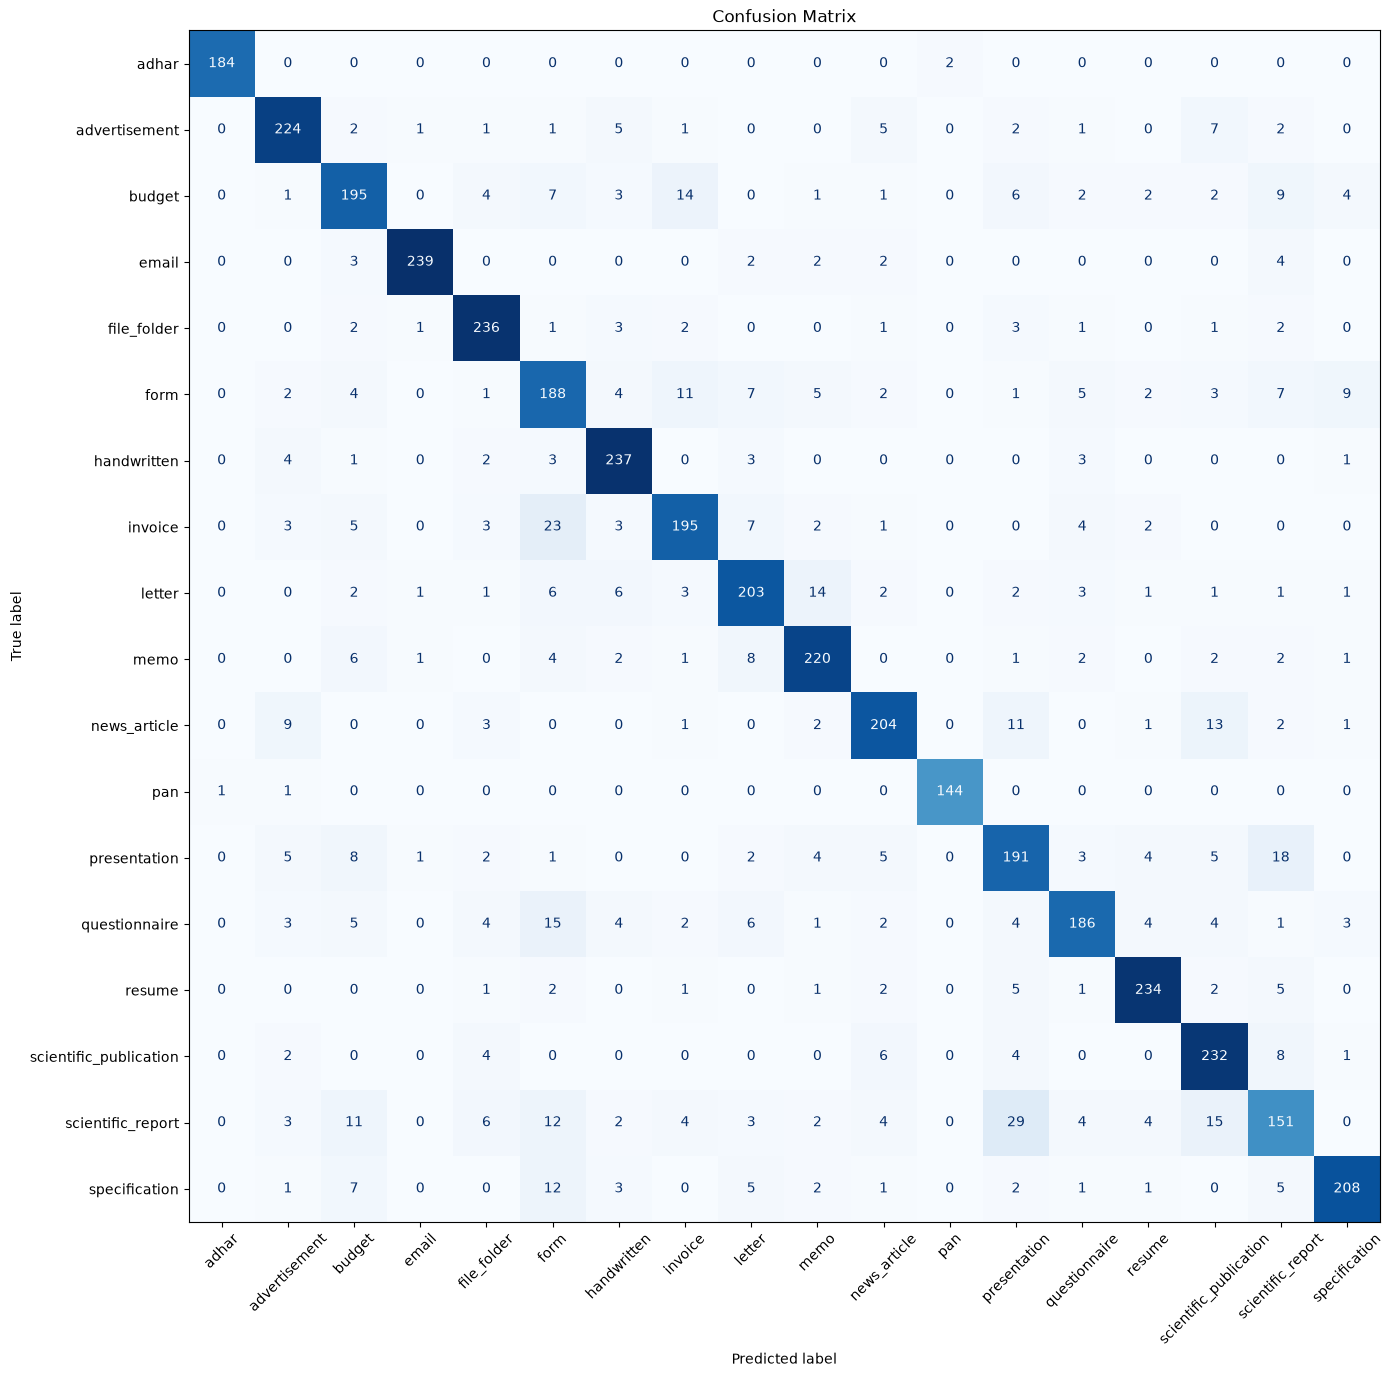

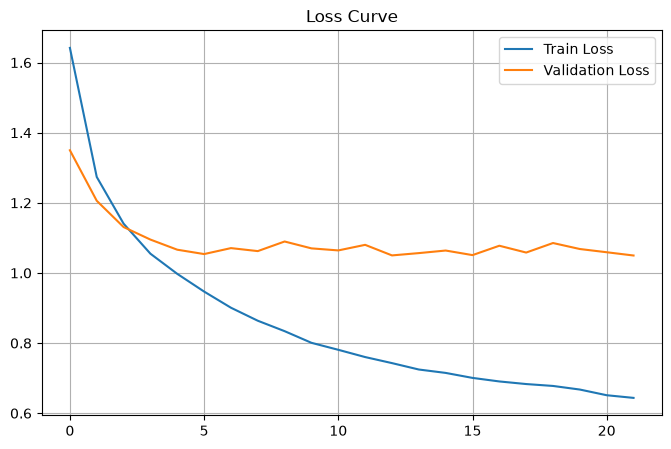

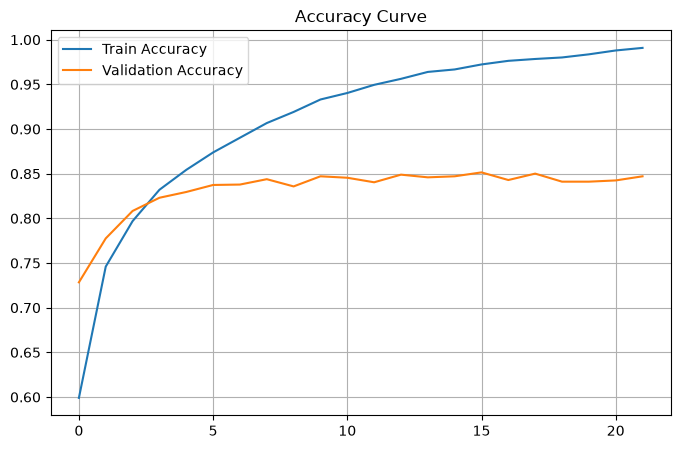


✅ Model Saved Successfully!
Saved as : general_document_classifier.pth


In [53]:
# ==========================================================
# FINAL EVALUATION
# ==========================================================

import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for images, labels in tqdm(test_loader, desc="Testing"):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=torch.cuda.is_available()
        ):
            outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_predictions.extend(preds.cpu().tolist())
        all_targets.extend(labels.cpu().tolist())

# ==========================================================
# METRICS
# ==========================================================

test_accuracy = accuracy_score(all_targets, all_predictions)
test_precision = precision_score(all_targets, all_predictions, average="weighted", zero_division=0)
test_recall = recall_score(all_targets, all_predictions, average="weighted", zero_division=0)
test_f1 = f1_score(all_targets, all_predictions, average="weighted", zero_division=0)

print("=" * 60)
print("TEST RESULTS")
print("=" * 60)
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report\n")

print(classification_report(
    all_targets,
    all_predictions,
    target_names=train_dataset.classes,
    digits=4
))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(all_targets, all_predictions)

fig, ax = plt.subplots(figsize=(14,14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ==========================================================
# TRAINING CURVES
# ==========================================================

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid(True)
plt.title("Loss Curve")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.legend()
plt.grid(True)
plt.title("Accuracy Curve")
plt.show()

# ==========================================================
# SINGLE IMAGE PREDICTION
# ==========================================================

def predict_document(image_path):

    image = Image.open(image_path).convert("RGB")

    tensor = test_transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        with torch.amp.autocast(
            device_type=device.type,
            enabled=torch.cuda.is_available()
        ):

            output = model(tensor)
            probabilities = torch.softmax(output, dim=1)

        confidence, prediction = torch.max(probabilities, dim=1)

        top3_prob, top3_idx = torch.topk(
            probabilities,
            k=min(3, len(train_dataset.classes))
        )

    class_name = train_dataset.classes[prediction.item()]

    print("=" * 60)
    print(f"Prediction : {class_name}")
    print(f"Confidence : {confidence.item()*100:.2f}%")

    print("\nTop Predictions")

    for prob, idx in zip(top3_prob[0], top3_idx[0]):
        print(f"{train_dataset.classes[idx.item()]} : {prob.item()*100:.2f}%")

    print("=" * 60)

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.title(f"{class_name}\n{confidence.item()*100:.2f}%")
    plt.axis("off")
    plt.show()

# ==========================================================
# SAVE BEST MODEL
# ==========================================================

model.load_state_dict(best_model_weights)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "classes": train_dataset.classes,
        "num_classes": NUM_CLASSES
    },
    "general_document_classifier.pth"
)

print("\n✅ Model Saved Successfully!")
print("Saved as : general_document_classifier.pth")